# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configure visualization style
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
%matplotlib inline

print('Libraries imported successfully.')

Libraries imported successfully.


# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [ ]:
# Load the dataset
file_path = '/content/Retail_Transactions_Dataset.csv'
df = pd.read_csv(file_path)

# Display basic info and the first few rows
print(f'Dataset Shape: {df.shape}')
display(df.info())
display(df.head())

Dataset Shape: (49497, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49497 entries, 0 to 49496
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Transaction_ID     49497 non-null  int64  
 1   Date               49497 non-null  object 
 2   Customer_Name      49497 non-null  object 
 3   Product            49496 non-null  object 
 4   Total_Items        49496 non-null  float64
 5   Total_Cost         49496 non-null  float64
 6   Payment_Method     49496 non-null  object 
 7   City               49496 non-null  object 
 8   Store_Type         49496 non-null  object 
 9   Discount_Applied   49496 non-null  object 
 10  Customer_Category  49496 non-null  object 
 11  Season             49496 non-null  object 
 12  Promotion          33010 non-null  object 
dtypes: float64(2), int64(1), object(10)
memory usage: 4.9+ MB


None

,Transaction_ID,Date,Customer_Name,Product,Total_Items,Total_Cost,Payment_Method,City,Store_Type,Discount_Applied,Customer_Category,Season,Promotion
0,1000000000,2022-01-21 06:27:29,Stacey Price,"['Ketchup', 'Shaving Cream', 'Light Bulbs']",3.0,71.65,Mobile Payment,Los Angeles,Warehouse Club,True,Homemaker,Winter,NaN
1,1000000001,2023-03-01 13:01:21,Michelle Carlson,"['Ice Cream', 'Milk', 'Olive Oil', 'Bread', 'P...",2.0,25.93,Cash,San Francisco,Specialty Store,True,Professional,Fall,BOGO (Buy One Get One)
2,1000000002,2024-03-21 15:37:04,Lisa Graves,['Spinach'],6.0,41.49,Credit Card,Houston,Department Store,True,Professional,Winter,NaN
3,1000000003,2020-10-31 09:59:47,Mrs. Patricia May,"['Tissues', 'Mustard']",1.0,39.34,Mobile Payment,Chicago,Pharmacy,True,Homemaker,Spring,NaN
4,1000000004,2020-12-10 00:59:59,Susan Mitchell,['Dish Soap'],10.0,16.42,Debit Card,Houston,Specialty Store,False,Young Adult,Winter,Discount on Selected Items


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

,Transaction_ID,Total_Items,Total_Cost
count,4.949700e+04,49496.000000,49496.000000
mean,1.000025e+09,5.507657,52.418279
std,1.428870e+04,2.883687,27.431653
min,1.000000e+09,1.000000,5.000000
25%,1.000012e+09,3.000000,28.720000
50%,1.000025e+09,6.000000,52.390000
75%,1.000037e+09,8.000000,76.162500
max,1.000049e+09,10.000000,100.000000


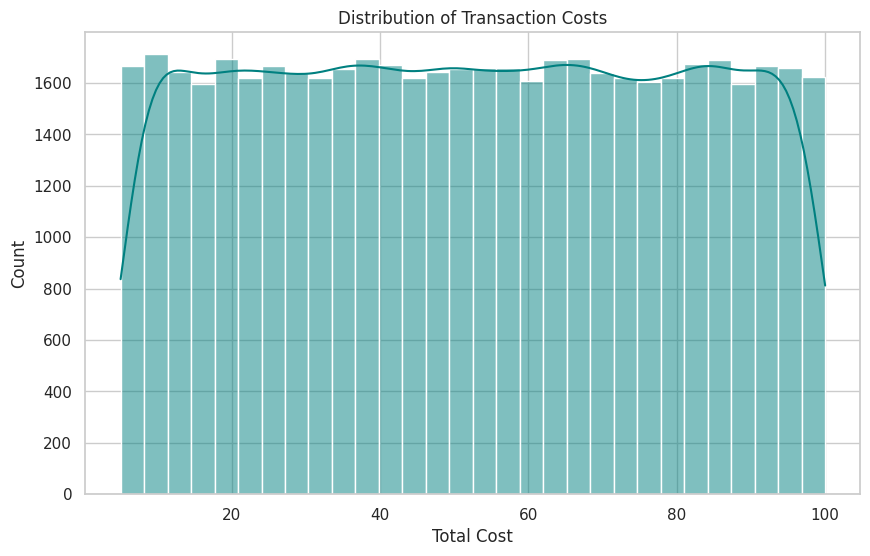

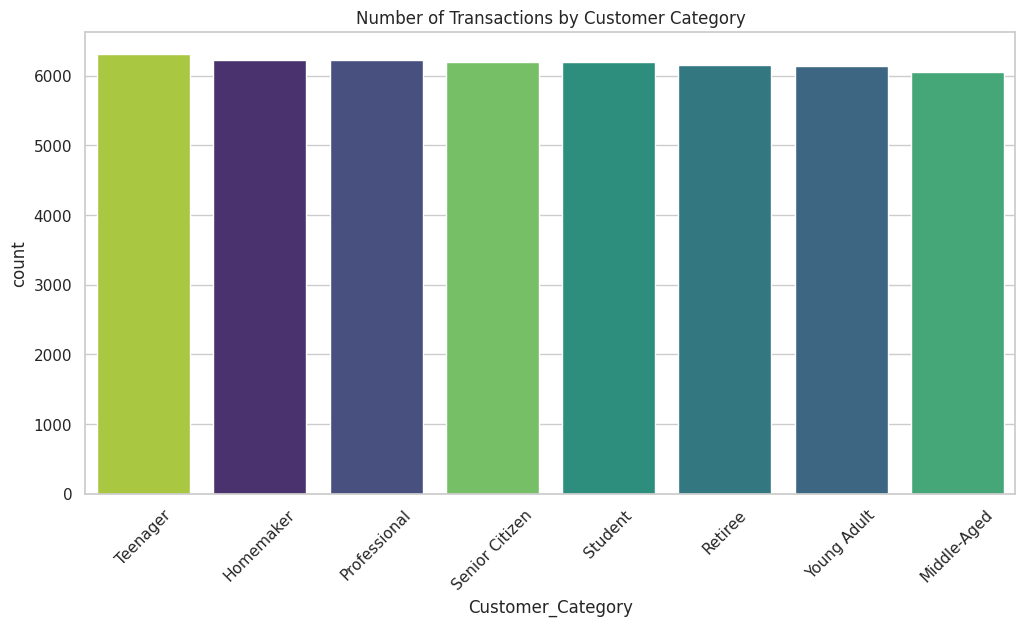

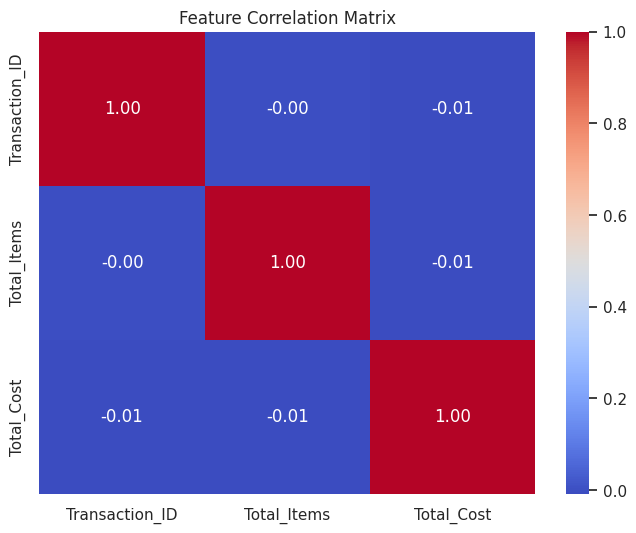

In [ ]:
# Statistical Summary
display(df.describe())

# 1. Distribution of Total Cost
plt.figure(figsize=(10, 6))
sns.histplot(df['Total_Cost'], bins=30, kde=True, color='teal')
plt.title('Distribution of Transaction Costs')
plt.xlabel('Total Cost')
plt.show()

# 2. Transaction count by Customer Category
if 'Customer_Category' in df.columns:
    plt.figure(figsize=(12, 6))
    # Updated to follow seaborn v0.14.0 best practices
    sns.countplot(
        data=df,
        x='Customer_Category',
        hue='Customer_Category',
        palette='viridis',
        order=df['Customer_Category'].value_counts().index,
        legend=False
    )
    plt.title('Number of Transactions by Customer Category')
    plt.xticks(rotation=45)
    plt.show()

# 3. Correlation Heatmap (numeric only)
plt.figure(figsize=(8, 6))
sns.heatmap(df.select_dtypes(include=[np.number]).corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Matrix')
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [ ]:
# 1. Handle Missing Values
missing_data = df.isnull().sum()
print("Missing values per column:\n", missing_data[missing_data > 0])

# 2. Convert Date columns
if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'])

# 3. Handle Duplicates
duplicate_count = df.duplicated().sum()
if duplicate_count > 0:
    print(f'Removing {duplicate_count} duplicate rows...')
    df = df.drop_duplicates()

# 4. Feature Engineering: Extracting Date Features
if 'Date' in df.columns:
    df['Month'] = df['Date'].dt.month
    df['DayOfWeek'] = df['Date'].dt.day_name()

# 5. Check for Outliers (Z-Score method for Total Cost)
from scipy import stats
z_scores = np.abs(stats.zscore(df['Total_Cost']))
outliers = df[z_scores > 3]
print(f'Identified {len(outliers)} outliers in Total_Cost (Z > 3)')

print('Preprocessing complete.')
display(df.head())

Missing values per column:
 Product                  1
Total_Items              1
Total_Cost               1
Payment_Method           1
City                     1
Store_Type               1
Discount_Applied         1
Customer_Category        1
Season                   1
Promotion            16487
dtype: int64
Identified 0 outliers in Total_Cost (Z > 3)
Preprocessing complete.


,Transaction_ID,Date,Customer_Name,Product,Total_Items,Total_Cost,Payment_Method,City,Store_Type,Discount_Applied,Customer_Category,Season,Promotion,Month,DayOfWeek
0,1000000000,2022-01-21 06:27:29,Stacey Price,"['Ketchup', 'Shaving Cream', 'Light Bulbs']",3.0,71.65,Mobile Payment,Los Angeles,Warehouse Club,True,Homemaker,Winter,NaN,1,Friday
1,1000000001,2023-03-01 13:01:21,Michelle Carlson,"['Ice Cream', 'Milk', 'Olive Oil', 'Bread', 'P...",2.0,25.93,Cash,San Francisco,Specialty Store,True,Professional,Fall,BOGO (Buy One Get One),3,Wednesday
2,1000000002,2024-03-21 15:37:04,Lisa Graves,['Spinach'],6.0,41.49,Credit Card,Houston,Department Store,True,Professional,Winter,NaN,3,Thursday
3,1000000003,2020-10-31 09:59:47,Mrs. Patricia May,"['Tissues', 'Mustard']",1.0,39.34,Mobile Payment,Chicago,Pharmacy,True,Homemaker,Spring,NaN,10,Saturday
4,1000000004,2020-12-10 00:59:59,Susan Mitchell,['Dish Soap'],10.0,16.42,Debit Card,Houston,Specialty Store,False,Young Adult,Winter,Discount on Selected Items,12,Thursday


In [ ]:
# Export the cleaned dataframe to a CSV file
output_filename = 'dataset_preprocessing.csv'
df.to_csv(output_filename, index=False)

print(f'Dataset berhasil diekspor sebagai: {output_filename}')

Dataset berhasil diekspor sebagai: dataset_preprocessing.csv
